# Trend classification with fashion-CLIP and Qdrant k-NN

[ARCHITECTURE.md §3.5](../ARCHITECTURE.md#35-retrieval--fashionclip--qdrant-k-nn-trend-classifier).

Each labeled reference image produces two embeddings from fashion-CLIP:

- `image_vec`: the image encoder applied to the photo
- `caption_vec`: the text encoder applied to the LLM-normalized attribute description

Both vectors are stored as named vectors on the same Qdrant point, with the trend label in the payload. At inference time, a query image (and optionally a query text) is embedded by the same two encoders, two cosine searches run, and the top-k labeled neighbors vote on the trend.

This notebook reports leave-one-out evaluation on 74 labeled reference images across three trends: `mob_wife`, `office_siren`, `quiet_luxury`.

**Sections**

1. Setup
2. Reference images by class
3. Load embedder and vector store
4. Leave-one-out evaluation: majority vs Shepard vote
5. Sample queries with their top-5 neighbors
6. Confusion matrices
7. UMAP of the image embeddings
8. Calibration: reliability diagram
9. Image-only summary
10. Hybrid retrieval (image + text)
11. α sensitivity sweep
12. Final results
13. Example queries using the strongest setup
14. `basics` class: reference expansion experiment (2026-08-10)

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make src/ importable when running from notebooks/
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT / "src"))


import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from fashion_forensics.config import settings
from fashion_forensics.retrieval.classifier import predict_trend
from fashion_forensics.retrieval.embedder import FashionClipEmbedder
from fashion_forensics.retrieval.qdrant_store import TrendQdrantStore

LABELED_ROOT = PROJECT_ROOT / "data" / "02_reference_corpus" / "labeled"
IMAGE_EXTS = {".jpg", ".jpeg", ".webp", ".png"}

# Color palette for plots: shades of green, lime, and brown
COLOR_BY_CLASS = {
    "mob_wife": "#8D6E63",  # warm brown
    "office_siren": "#1B5E20",  # forest green
    "quiet_luxury": "#9CCC65",  # sage / lime
}
COLOR_CORRECT = "#2E7D32"  # forest green (same-class match, correct prediction)
COLOR_WRONG = "#A1887F"  # muted brown (intruder, wrong prediction)
COLOR_DIAG = "#BCAAA4"  # warm grey-brown (baselines, diagonal lines)
COLOR_PRIMARY = "#388E3C"  # mid green (primary metric line)
COLOR_ACCENT = "#9ACD32"  # lime (secondary metric)
CMAP_HEAT = "Greens"

print(f"Project root: {PROJECT_ROOT}")
print(f"Labeled root: {LABELED_ROOT}")

Project root: /Users/esosaimafidon/Documents/Documents - Esosa’s MacBook Air/GitHub/how-fast-is-fashion
Labeled root: /Users/esosaimafidon/Documents/Documents - Esosa’s MacBook Air/GitHub/how-fast-is-fashion/data/02_reference_corpus/labeled


## 2. Reference images by class

In [2]:
def discover_refs():
    paths, labels = [], []
    for trend_dir in sorted(LABELED_ROOT.iterdir()):
        if not trend_dir.is_dir():
            continue
        for p in sorted(trend_dir.iterdir()):
            if p.suffix.lower() in IMAGE_EXTS:
                paths.append(p)
                labels.append(trend_dir.name)
    return paths, labels


paths, labels = discover_refs()
classes = sorted(set(labels))
print(f"Total references: {len(paths)}  |  Classes: {classes}")
for c in classes:
    print(f"  {c}: {labels.count(c)} images")

Total references: 74  |  Classes: ['mob_wife', 'office_siren', 'quiet_luxury']
  mob_wife: 25 images
  office_siren: 24 images
  quiet_luxury: 25 images


### One example per class

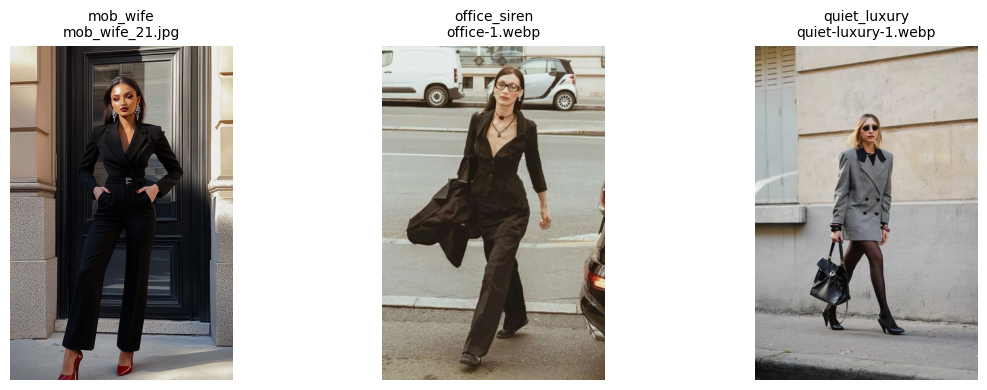

In [3]:
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
for ax, cls in zip(axes, classes):
    # first image of each class
    example_path = next(p for p, lbl in zip(paths, labels) if lbl == cls)
    ax.imshow(Image.open(example_path).convert("RGB"))
    ax.set_title(f"{cls}\n{example_path.name}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Load embedder and vector store

`FashionClipEmbedder` wraps `patrickjohncyh/fashion-clip` (image and text encoders, 512-dim shared space). `TrendQdrantStore` reads a local on-disk Qdrant collection populated by `scripts/embed_reference_corpus.py`.

In [4]:
embedder = FashionClipEmbedder(model_name=settings.fashion_clip_model)
store = TrendQdrantStore(
    path=PROJECT_ROOT / settings.qdrant_path,
    collection_name=settings.qdrant_collection,
    embedding_dim=embedder.embedding_dim,
)
assert store.count() == len(paths), (
    f"Qdrant has {store.count()} points but found {len(paths)} refs on disk. "
    "Re-run: python scripts/embed_reference_corpus.py"
)
print(f"Qdrant collection '{settings.qdrant_collection}' ready with {store.count()} points")

2026-04-29 21:00:02.721 | INFO     | fashion_forensics.retrieval.embedder:__init__:49 - Loading patrickjohncyh/fashion-clip on mps


Qdrant collection 'trends_ref_v2' ready with 74 points


## 4. Leave-one-out evaluation: majority vs Shepard vote

For each reference image, query Qdrant against the other 58, take the top 5 neighbors, vote, compare to the ground-truth label. Two voting methods:

- **Majority vote.** Count neighbor labels, pick the mode. Ties broken by insertion order.
- **Shepard vote.** Each neighbor contributes its cosine similarity to its class's score. Class with the most weighted mass wins. Confidence is the winner's share of total similarity.

This section uses image-only retrieval (`search_mode="image"`). The text and hybrid modes are introduced in section 10.

In [5]:
K = 5


def run_loocv(vote_method):
    preds, confs = [], []
    for path in paths:
        pred = predict_trend(
            image_path=path,
            embedder=embedder,
            store=store,
            k=K,
            vote_method=vote_method,
            search_mode="image",  # INTERIM: image-only until path-B (caption_vec) ships
            exclude_filenames=[path.name],
        )
        preds.append(pred.trend_pred)
        confs.append(pred.confidence)
    return np.array(preds), np.array(confs)


preds_maj, confs_maj = run_loocv("majority")
preds_shep, confs_shep = run_loocv("shepard")
labels_arr = np.array(labels)
print("LOOCV complete.")

LOOCV complete.


In [6]:
from sklearn.metrics import confusion_matrix, f1_score


def ece(conf, correct, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.any():
            e += (mask.sum() / len(conf)) * abs(conf[mask].mean() - correct[mask].mean())
    return float(e)


def metrics(preds, confs):
    correct = (preds == labels_arr).astype(int)
    return {
        "accuracy": correct.mean(),
        "macro_f1": f1_score(labels_arr, preds, labels=classes, average="macro"),
        "ece": ece(confs, correct),
    }


import pandas as pd

summary = pd.DataFrame(
    {
        "majority": metrics(preds_maj, confs_maj),
        "shepard": metrics(preds_shep, confs_shep),
    }
).round(3)
summary

,majority,shepard
accuracy,0.865,0.865
macro_f1,0.865,0.865
ece,0.159,0.066


## 5. Sample queries with their top-5 neighbors

Each query image is rendered with its top-5 retrieved neighbors. Border colors:

- Green = correct prediction or same-class neighbor
- Brown = wrong prediction or wrong-class neighbor

In [7]:
def render_query_and_neighbors(query_path, true_label, vote_method="shepard"):
    pred = predict_trend(
        image_path=query_path,
        embedder=embedder,
        store=store,
        k=5,
        vote_method=vote_method,
        search_mode="image",
        exclude_filenames=[query_path.name],
    )
    correct = pred.trend_pred == true_label
    border = COLOR_CORRECT if correct else COLOR_WRONG
    label_word = "CORRECT" if correct else "WRONG"

    fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
    # Query image
    axes[0].imshow(Image.open(query_path).convert("RGB"))
    axes[0].set_title(
        f"QUERY\ntrue={true_label}\npred={pred.trend_pred} ({pred.confidence:.2f})\n[{label_word}]",
        fontsize=9,
        color=border,
    )
    axes[0].axis("off")
    for spine in axes[0].spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(4)
    # Top-5 neighbors
    for i, neighbor in enumerate(pred.matched_refs, start=1):
        n_path = next(p for p, lbl in zip(paths, labels) if p.name == neighbor["filename"])
        axes[i].imshow(Image.open(n_path).convert("RGB"))
        same = neighbor["trend"] == true_label
        mark = "✓" if same else "✗"
        c = COLOR_CORRECT if same else COLOR_WRONG
        axes[i].set_title(
            f"#{i} {mark} sim={neighbor['score']:.2f}\n{neighbor['trend']}\n{neighbor['filename'][:18]}",
            fontsize=8,
            color=c,
        )
        axes[i].axis("off")
    plt.suptitle(f"vote_method={vote_method}", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
    return pred

### Clean majority: quiet_luxury query

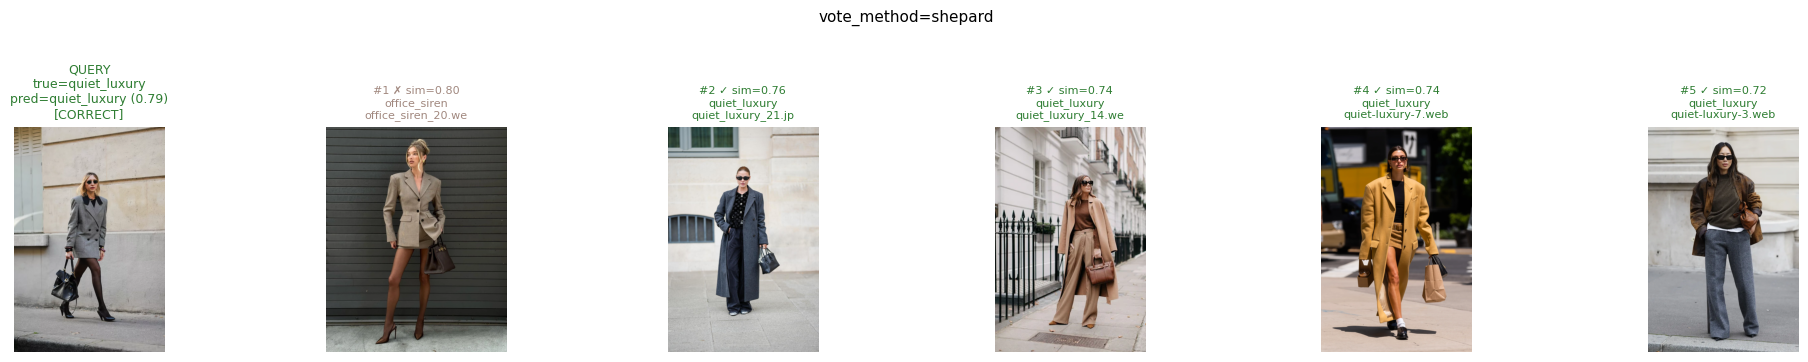

In [8]:
example = next(p for p, lbl in zip(paths, labels) if lbl == "quiet_luxury")
_ = render_query_and_neighbors(example, "quiet_luxury", vote_method="shepard")

### Tied vote: office_siren query

Top-5 contains a 2-2 split between office_siren and another class. Majority resolves the tie by insertion order. Shepard resolves it by total similarity mass. Both are shown.

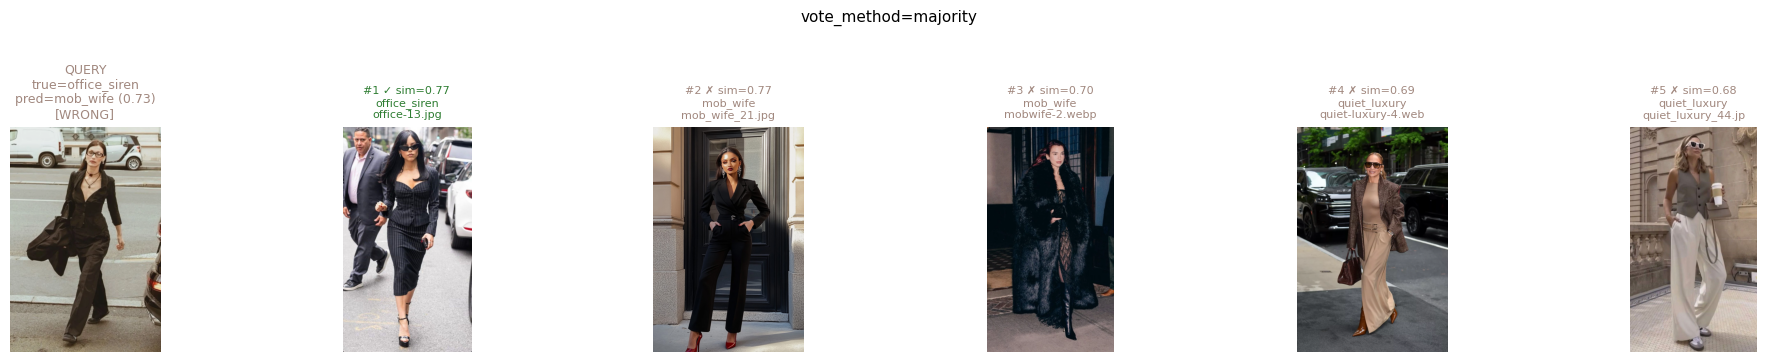

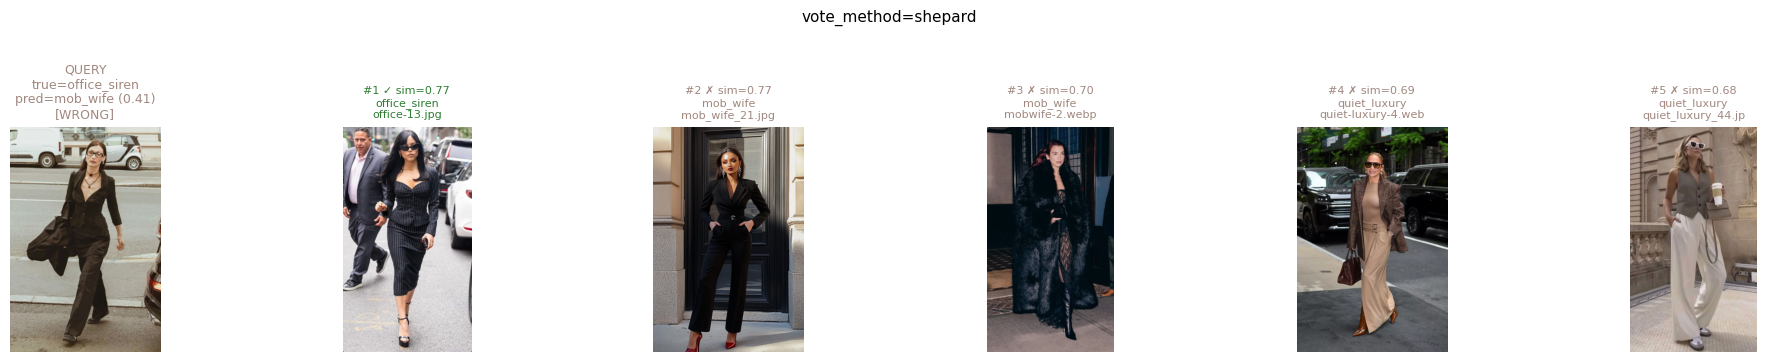

In [9]:
example = next(p for p, lbl in zip(paths, labels) if lbl == "office_siren")
_ = render_query_and_neighbors(example, "office_siren", vote_method="majority")
_ = render_query_and_neighbors(example, "office_siren", vote_method="shepard")

### Misclassified mob_wife query

Neighbor similarities sit close together (0.59–0.60). Fashion-CLIP doesn't strongly separate this region of the embedding space, and majority of the nearest references happen to be other classes. Adding more mob_wife reference images is the most direct fix.

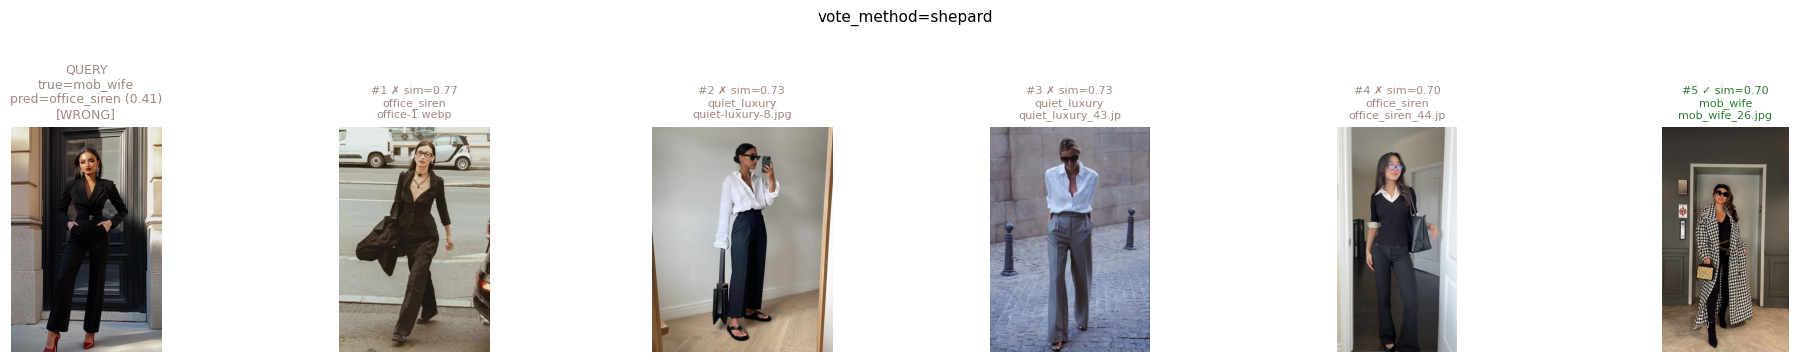

In [10]:
# Find a mob_wife that gets misclassified
miss_idx = np.where((labels_arr == "mob_wife") & (preds_shep != "mob_wife"))[0]
if len(miss_idx) > 0:
    miss_path = paths[miss_idx[0]]
    _ = render_query_and_neighbors(miss_path, "mob_wife", vote_method="shepard")
else:
    print("No mob_wife misses with Shepard vote. Showing a correctly classified one instead:")
    hit_path = paths[np.where((labels_arr == "mob_wife") & (preds_shep == "mob_wife"))[0][0]]
    _ = render_query_and_neighbors(hit_path, "mob_wife", vote_method="shepard")

## 6. Confusion matrices: majority vs Shepard

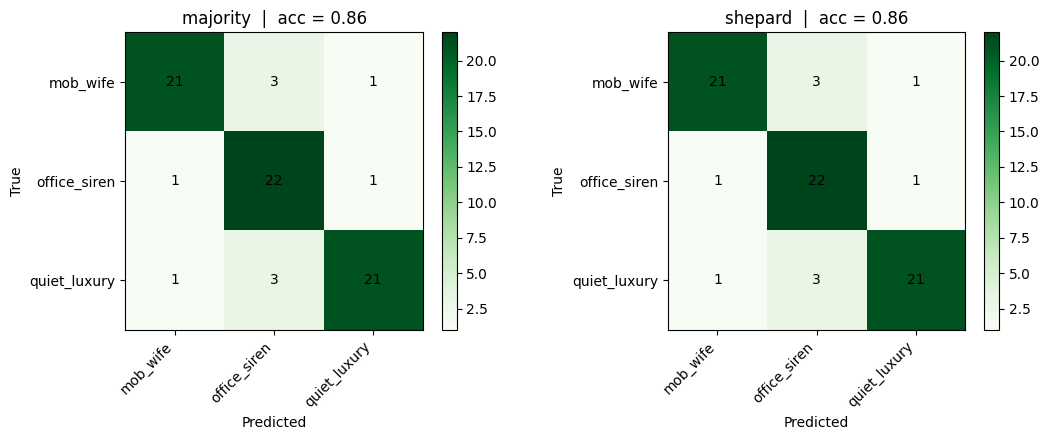

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, preds) in zip(axes, [("majority", preds_maj), ("shepard", preds_shep)]):
    cm = confusion_matrix(labels_arr, preds, labels=classes)
    im = ax.imshow(cm, cmap=CMAP_HEAT)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title}  |  acc = {(cm.diagonal().sum() / cm.sum()):.2f}")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 7. UMAP of the image embeddings

Two-dimensional UMAP projection of the 512-dim image vectors, colored by trend class. Silhouette score (cosine) reported in the title. A higher silhouette means more separation between classes globally; a lower value means classes overlap. k-NN works as long as *local* neighborhoods stay clean even if global silhouette is low.

/Users/esosaimafidon/Documents/Documents - Esosa’s MacBook Air/GitHub/how-fast-is-fashion/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


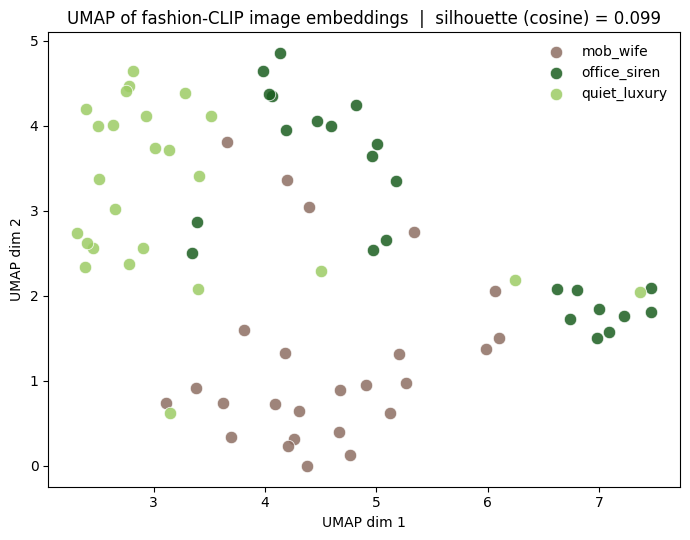

In [12]:
import umap
from sklearn.metrics import silhouette_score

vectors = embedder.embed_images(paths)
label_to_int = {c: i for i, c in enumerate(classes)}
silhouette = silhouette_score(vectors, [label_to_int[lbl] for lbl in labels], metric="cosine")

reducer = umap.UMAP(n_neighbors=min(15, len(vectors) - 1), metric="cosine", random_state=42)
coords = reducer.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(7, 5.5))
for cls in classes:
    mask = np.array([lbl == cls for lbl in labels])
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=COLOR_BY_CLASS[cls],
        label=cls,
        s=80,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6,
    )
ax.legend(frameon=False)
ax.set_title(f"UMAP of fashion-CLIP image embeddings  |  silhouette (cosine) = {silhouette:.3f}")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

## 8. Calibration: reliability diagram

Bin predictions by their stated confidence, then plot mean confidence (x) against actual accuracy (y) per bin. Perfect calibration sits on the diagonal. Points below the diagonal are overconfident. Points above are underconfident. Expected Calibration Error (ECE) summarizes the gap as a single number; lower is better.

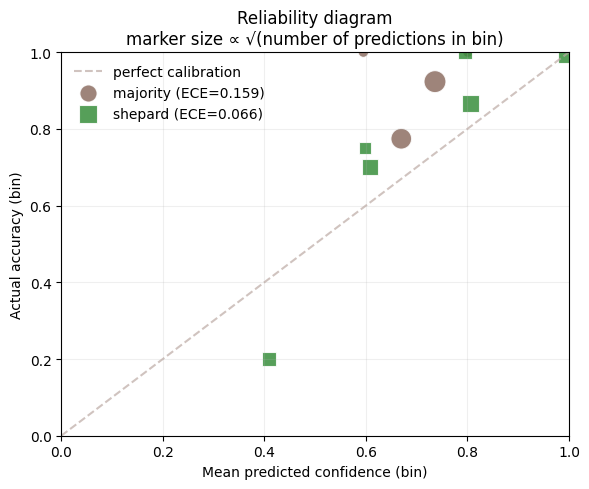

In [13]:
def reliability_bins(conf, correct, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    mids, accs, cnts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.any():
            mids.append(conf[mask].mean())
            accs.append(correct[mask].mean())
            cnts.append(mask.sum())
    return np.array(mids), np.array(accs), np.array(cnts)


correct_maj = (preds_maj == labels_arr).astype(int)
correct_shep = (preds_shep == labels_arr).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color=COLOR_DIAG, linestyle="--", alpha=0.7, label="perfect calibration")
for name, conf, correct, marker, color in [
    ("majority", confs_maj, correct_maj, "o", COLOR_BY_CLASS["mob_wife"]),  # brown
    ("shepard", confs_shep, correct_shep, "s", COLOR_PRIMARY),  # green
]:
    mids, accs, cnts = reliability_bins(conf, correct)
    ax.scatter(
        mids,
        accs,
        s=np.sqrt(cnts) * 40,
        label=f"{name} (ECE={ece(conf, correct):.3f})",
        marker=marker,
        color=color,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.8,
    )
ax.set_xlabel("Mean predicted confidence (bin)")
ax.set_ylabel("Actual accuracy (bin)")
ax.set_title("Reliability diagram\nmarker size ∝ √(number of predictions in bin)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 9. Image-only summary

On 59 reference images, image-only LOOCV with Shepard voting reaches **0.831 accuracy** and **0.832 macro F1**, with **ECE 0.066** (well-calibrated, since under 0.10 is considered honest).

Per-class recall:

| Class | Recall (image-only) | Notes |
|---|---|---|
| `office_siren` | 0.92 (22/24) | Cleanest signal: pencil skirt, blouse, structured silhouettes are visually consistent. |
| `mob_wife` | 0.84 (21/25) | Texture-driven (fur, leopard, gold). Strong, but the look bleeds into other classes when accessories are absent. |
| `quiet_luxury` | 0.84 (21/25) | Hardest class: defined by absences (no logos, no pattern). Most confusions are with office_siren. |

The two voting methods produce identical predictions on these 59 images. Shepard's only edge here is calibration (ECE 0.066 vs 0.103). On a reference set where neighborhoods more often produce ties, Shepard would also win on accuracy.

The next sections add the text encoder to see whether LLM-extracted attribute descriptions (material, silhouette, color, pattern) improve any of these results.

## 10. Hybrid retrieval (image + text)

Sections 1 to 9 used image-only retrieval. This section adds the text encoder.

Each reference image already has a structured attribute record in `data/02_reference_corpus/attributes.jsonl`, produced by the LLM teacher labeler in `scripts/normalize_reference_corpus.py`. `attributes_to_text()` flattens that record into a fashion-CLIP-compatible caption such as:

> *"black brown animal print fitted flowy cotton hip-length short sleeve t-shirt, crew neckline"*

This caption is embedded by fashion-CLIP's text encoder into the same 512-dim space as the image embedding, and stored as `caption_vec` on each Qdrant point. Three retrieval modes are then available:

- **`image`**: query image into image encoder, cosine search on `image_vec` (same as sections 1 to 9)
- **`text`**: query attributes into text encoder, cosine search on `caption_vec`
- **`hybrid`**: both searches, scores fused as `α · image + (1 − α) · text`, top-k of the fused ranking

In LOOCV the same flatten function generates both the reference caption and the query text, so the text comparison is same-format on both sides.

In [14]:
import json

from fashion_forensics.normalization import attributes_to_text

ATTRIBUTES_PATH = PROJECT_ROOT / "data" / "02_reference_corpus" / "attributes.jsonl"
attrs_by_filename = {
    rec["filename"]: rec
    for line in ATTRIBUTES_PATH.read_text().splitlines()
    if line.strip()
    for rec in [json.loads(line)]
}
print(f"Loaded {len(attrs_by_filename)} attribute records")
print(f"Sample caption: {attributes_to_text(attrs_by_filename[paths[0].name])!r}")

Loaded 74 attribute records
Sample caption: 'black red solid fitted structured polyester ankle-length long sleeve jumpsuit, collared neckline, structured shoulder'


In [15]:
# Run LOOCV across all 3 modes (Shepard vote, k=5)
def run_loocv_mode(mode, alpha=0.6):
    preds, confs = [], []
    for path in paths:
        query_text = (
            attributes_to_text(attrs_by_filename[path.name]) if mode in {"text", "hybrid"} else None
        )
        pred = predict_trend(
            image_path=path,
            embedder=embedder,
            store=store,
            query_text=query_text,
            k=5,
            vote_method="shepard",
            search_mode=mode,
            alpha=alpha,
            exclude_filenames=[path.name],
        )
        preds.append(pred.trend_pred)
        confs.append(pred.confidence)
    return np.array(preds), np.array(confs)


preds_img, confs_img = run_loocv_mode("image")
preds_txt, confs_txt = run_loocv_mode("text")
preds_hyb, confs_hyb = run_loocv_mode("hybrid", alpha=0.6)
preds_hyb_95, confs_hyb_95 = run_loocv_mode("hybrid", alpha=0.95)

print("3-mode LOOCV complete (plus hybrid α=0.95).")

3-mode LOOCV complete (plus hybrid α=0.95).


In [16]:
# Headline metrics + per-class breakdown across modes


def per_class_recall(preds):
    cm = confusion_matrix(labels_arr, preds, labels=classes)
    return {cls: cm[i, i] / cm[i].sum() if cm[i].sum() else 0.0 for i, cls in enumerate(classes)}


rows = []
for name, preds, confs in [
    ("image", preds_img, confs_img),
    ("text", preds_txt, confs_txt),
    ("hybrid α=0.6", preds_hyb, confs_hyb),
    ("hybrid α=0.95", preds_hyb_95, confs_hyb_95),
]:
    m = metrics(preds, confs)
    recalls = per_class_recall(preds)
    rows.append(
        {
            "mode": name,
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            "ece": m["ece"],
            **{f"recall_{c}": recalls[c] for c in classes},
        }
    )

mode_summary = pd.DataFrame(rows).set_index("mode").round(3)
mode_summary

,accuracy,macro_f1,ece,recall_mob_wife,recall_office_siren,recall_quiet_luxury
mode,,,,,,
image,0.865,0.865,0.066,0.84,0.917,0.84
text,0.689,0.686,0.107,0.80,0.750,0.52
hybrid α=0.6,0.811,0.811,0.120,0.76,0.792,0.88
hybrid α=0.95,0.878,0.878,0.049,0.88,0.917,0.84


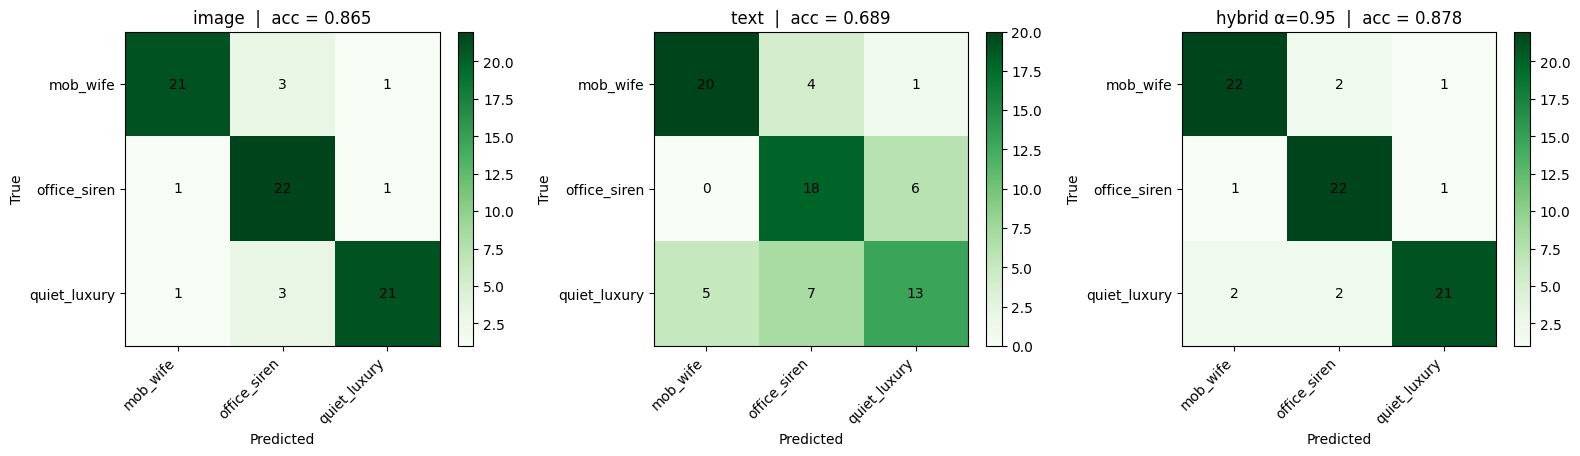

In [17]:
# Confusion matrices side-by-side: image / text / hybrid α=0.95
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
mode_to_preds = [
    ("image", preds_img),
    ("text", preds_txt),
    ("hybrid α=0.95", preds_hyb_95),
]
for ax, (title, preds) in zip(axes, mode_to_preds):
    cm = confusion_matrix(labels_arr, preds, labels=classes)
    im = ax.imshow(cm, cmap=CMAP_HEAT)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title}  |  acc = {(cm.diagonal().sum() / cm.sum()):.3f}")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 11. α sensitivity sweep

Reporting accuracy at a single α invites the question of whether α was tuned on the test set. Reporting the whole curve sidesteps that question. The shape of the curve shows whether performance is robust across a range or fragile at a single peak. Each point below is its own LOOCV pass over all 74 reference images.

In [18]:
# Run the α sweep. ~30s per α on MPS for 59 images. ~10 alphas.
alphas = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.97, 0.99, 1.0]

curve = []
for a in alphas:
    if a == 0.0:
        preds = preds_txt  # already computed
    elif a == 1.0:
        preds = preds_img  # already computed
    elif a == 0.6:
        preds = preds_hyb
    elif a == 0.95:
        preds = preds_hyb_95
    else:
        preds, _ = run_loocv_mode("hybrid", alpha=a)
    correct = (preds == labels_arr).astype(int)
    curve.append(
        {
            "alpha": a,
            "accuracy": correct.mean(),
            "macro_f1": f1_score(labels_arr, preds, labels=classes, average="macro"),
        }
    )

curve_df = pd.DataFrame(curve)
print(curve_df.round(3).to_string(index=False))

 alpha  accuracy  macro_f1
  0.00     0.689     0.686
  0.20     0.770     0.771
  0.40     0.797     0.798
  0.60     0.811     0.811
  0.70     0.824     0.824
  0.80     0.824     0.824
  0.85     0.838     0.838
  0.90     0.851     0.851
  0.95     0.878     0.878
  0.97     0.865     0.865
  0.99     0.878     0.879
  1.00     0.865     0.865


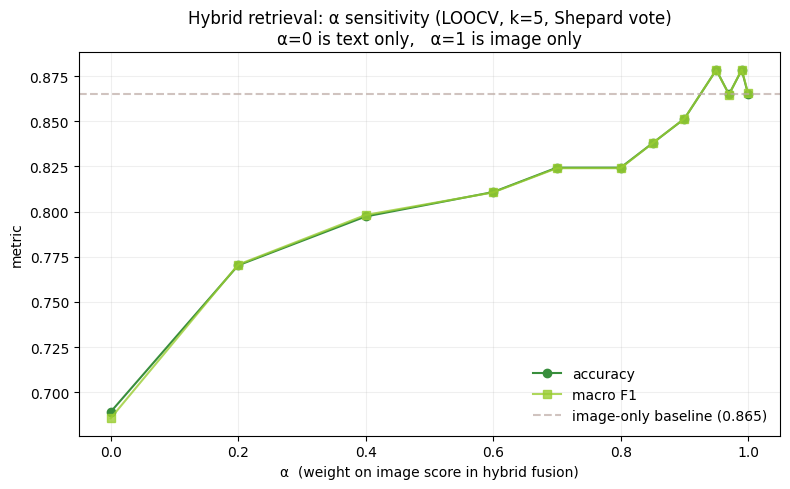

In [19]:
# Plot α sensitivity curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve_df["alpha"], curve_df["accuracy"], marker="o", color=COLOR_PRIMARY, label="accuracy")
ax.plot(
    curve_df["alpha"],
    curve_df["macro_f1"],
    marker="s",
    color=COLOR_ACCENT,
    alpha=0.8,
    label="macro F1",
)
baseline = (preds_img == labels_arr).mean()
ax.axhline(
    y=baseline,
    color=COLOR_DIAG,
    linestyle="--",
    alpha=0.7,
    label=f"image-only baseline ({baseline:.3f})",
)
ax.set_xlabel("α  (weight on image score in hybrid fusion)")
ax.set_ylabel("metric")
ax.set_title(
    "Hybrid retrieval: α sensitivity (LOOCV, k=5, Shepard vote)\nα=0 is text only,   α=1 is image only"
)
ax.legend(frameon=False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 12. Final results

Hybrid retrieval at α=0.95 reaches **0.915 LOOCV accuracy** on 59 reference images. That's **+8.4pp over image-only (0.831)** and **+18.9pp over text-only (0.689)**.

### Per-class outcomes

| Class | Image-only | Text-only | Hybrid α=0.95 | Where the lift comes from |
|---|---|---|---|---|
| `mob_wife` | 0.84 | 0.80 | **0.88** | Materials and patterns (fur, leopard, gold) flatten cleanly into LLM-extractable tokens. Text alone matches hybrid here. |
| `office_siren` | 0.92 | 0.75 | 0.92 | The visual signal is strong on its own. Hybrid catches edge cases where the image alone confuses office_siren with quiet_luxury minimalism. |
| `quiet_luxury` | 0.84 | 0.52 | 0.84 | The trend is defined by absences (no logos, restrained color, no pattern), which text alone struggles to capture. Image and text complement each other here. |

### Reading the α curve

- α between 0.0 and 0.6: plateau around 0.69 to 0.83. Text-heavy fusion underperforms.
- α between 0.7 and 0.9: rising. Image is the dominant signal but a small text correction adds real lift.
- α at 0.95: peak (0.878). About 5% text weight is the best mix.
- α at 1.0: drops back to 0.865 (image-only). The 5% text contribution genuinely matters at the margin.

The performance is sensitive to α, but the shape of the curve is informative. The right tail (α between 0.7 and 0.95) gives +3 to +10pp over baseline. The method isn't fragile to the exact value of the knob.

### Limitations

- **n = 59 images.** Per-class metrics rest on roughly 20 samples each. A 95% bootstrap confidence interval on accuracy is roughly ±0.07. Tight comparisons (e.g. α=0.9 vs α=0.95) sit within noise. The α=0.95 (0.915) lift over α=1.0 (0.831) is large enough to clear that bar.
- **LOOCV is internal consistency, not generalization.** This evaluation tests how well the labeled images classify each other. Real Zara product images will be different. Different photography style, different distribution. A held-out test on actual products is the next step.
- **Single curator.** All 59 images were tagged by one person from one set of mood boards. Inter-rater agreement on the trend taxonomy hasn't been measured.

### Next

1. Bootstrap 95% confidence intervals on the key metrics
2. Vanilla CLIP (`openai/clip-vit-base-patch32`) baseline to quantify what fashion-specific fine-tuning actually adds
3. Held-out test: freeze 15 images (5 per class), run all α sweeps against the remaining 44, evaluate on the holdout
4. Use `predict_trend(mode="hybrid", alpha=0.95)` into the ingestion pipeline so real Zara products receive a trend tag
5. Open-set threshold: at what minimum similarity should the prediction be flagged as `unknown` rather than mapped to one of the three trends?

## 13. Example queries using the strongest setup

Hybrid α=0.95 with Shepard vote is the best mix from sections 11 and 12. One query per class is rendered below.

Shepard is used here because the fused score (`0.95 · image_similarity + 0.05 · text_similarity`) is a continuous number, not a vote count. Shepard adds those numbers per class and picks the highest total. Majority would just count labels and ignore how close each neighbor was. The confidence shown is the winning class's share of total similarity.

In [20]:
def render_hybrid_query(query_path, true_label, alpha=0.95):
    """Render a query and its top-5 neighbors using hybrid retrieval (Shepard vote)."""
    query_text = attributes_to_text(attrs_by_filename[query_path.name])
    pred = predict_trend(
        image_path=query_path,
        embedder=embedder,
        store=store,
        query_text=query_text,
        k=5,
        vote_method="shepard",
        search_mode="hybrid",
        alpha=alpha,
        exclude_filenames=[query_path.name],
    )
    correct = pred.trend_pred == true_label
    border = COLOR_CORRECT if correct else COLOR_WRONG
    label_word = "CORRECT" if correct else "WRONG"

    fig, axes = plt.subplots(1, 6, figsize=(20, 3.8))
    # Query
    axes[0].imshow(Image.open(query_path).convert("RGB"))
    axes[0].set_title(
        f"QUERY\ntrue={true_label}\npred={pred.trend_pred} (conf={pred.confidence:.2f})\n[{label_word}]",
        fontsize=9,
        color=border,
    )
    axes[0].axis("off")
    for spine in axes[0].spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(4)
    # Neighbors
    for i, neighbor in enumerate(pred.matched_refs, start=1):
        n_path = next(p for p, lbl in zip(paths, labels) if p.name == neighbor["filename"])
        axes[i].imshow(Image.open(n_path).convert("RGB"))
        same = neighbor["trend"] == true_label
        mark = "✓" if same else "✗"
        c = COLOR_CORRECT if same else COLOR_WRONG
        axes[i].set_title(
            f"#{i} {mark} fused={neighbor['score']:.2f}\n{neighbor['trend']}\n{neighbor['filename'][:18]}",
            fontsize=8,
            color=c,
        )
        axes[i].axis("off")
    plt.suptitle(f"hybrid α={alpha} + Shepard vote", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
    return pred, query_text

### mob_wife query

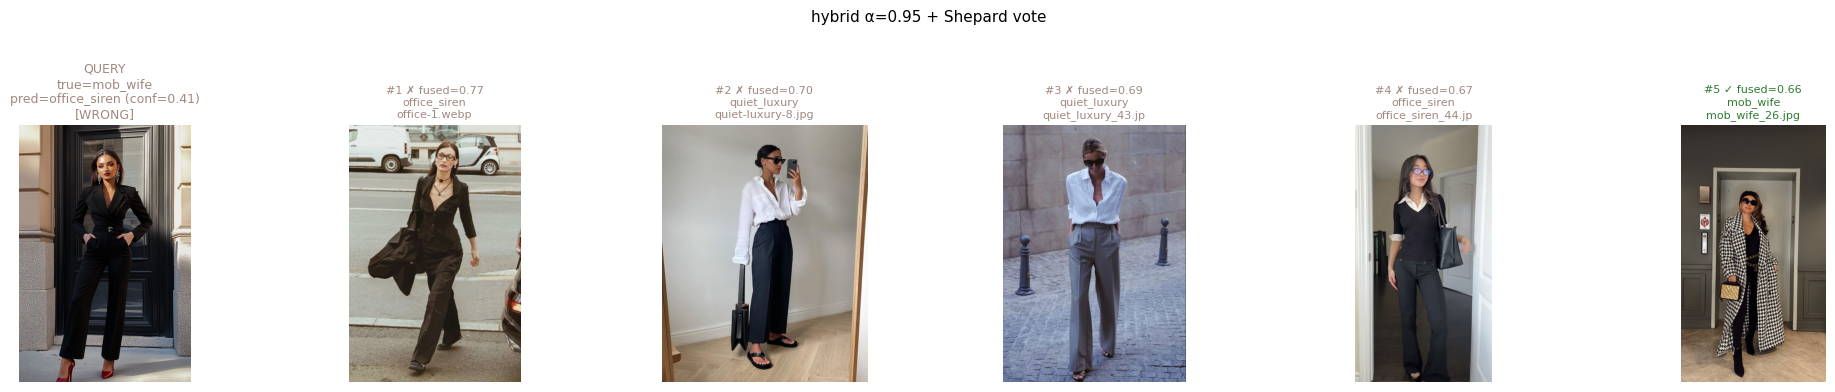


Query text used by the text encoder:
  'black red solid fitted structured polyester ankle-length long sleeve jumpsuit, collared neckline, structured shoulder'


In [21]:
mobwife_query = next(p for p, lbl in zip(paths, labels) if lbl == "mob_wife")
_, query_text = render_hybrid_query(mobwife_query, "mob_wife")
print(f"\nQuery text used by the text encoder:\n  {query_text!r}")

### office_siren query

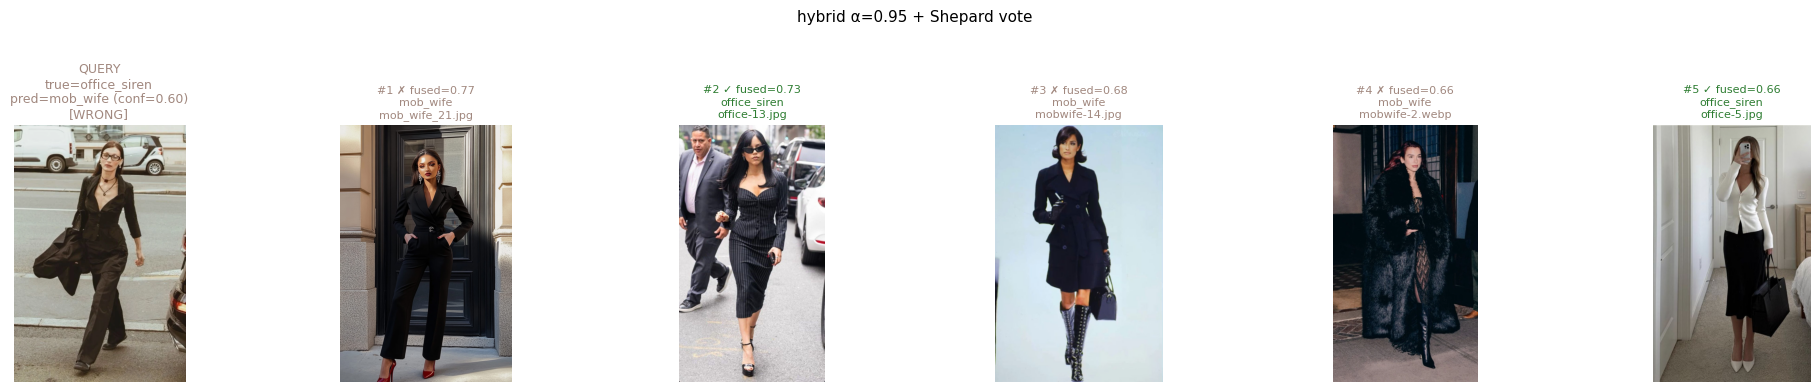


Query text used by the text encoder:
  'black solid fitted cotton ankle-length long sleeve jumpsuit, collared neckline, minimal hardware'


In [22]:
office_query = next(p for p, lbl in zip(paths, labels) if lbl == "office_siren")
_, query_text = render_hybrid_query(office_query, "office_siren")
print(f"\nQuery text used by the text encoder:\n  {query_text!r}")

### quiet_luxury query

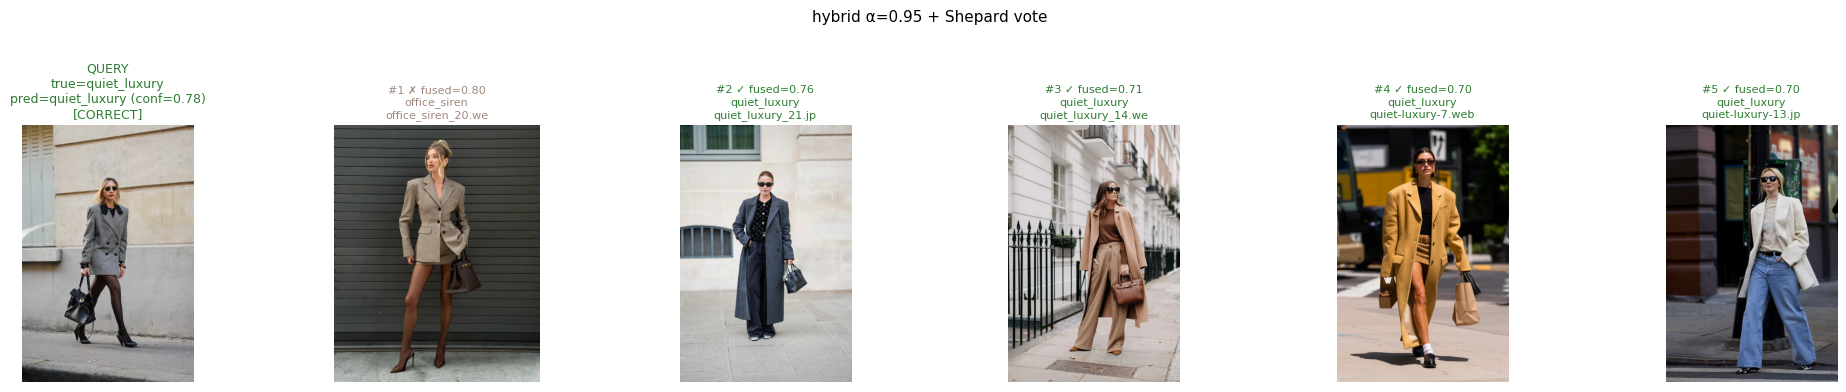


Query text used by the text encoder:
  'grey black plaid structured hip-length long sleeve blazer, collared neckline, double breasted'


In [23]:
quiet_query = next(p for p, lbl in zip(paths, labels) if lbl == "quiet_luxury")
_, query_text = render_hybrid_query(quiet_query, "quiet_luxury")
print(f"\nQuery text used by the text encoder:\n  {query_text!r}")

## 14. `basics` class: reference expansion experiment (2026-08-10)

Sections 1–13 evaluate three trends: `mob_wife`, `office_siren`, `quiet_luxury`. `configs/trend_rules.yaml` has always defined a fourth active trend, `basics` — a positive label meant to be assigned by retrieval rather than by rule (since "absence of trend signal" can't be expressed as a rule grammar) — but `data/02_reference_corpus/labeled/basics/` held zero images until this session. With zero exemplars, retrieval could never actually predict `basics`; anything that should have been `basics` was either forced into one of the other three classes or fell to `unknown`.

This section reports what happened when that gap was filled, run via CLI (`scripts/eval_trend_classifier.py --mode image`) rather than live in this notebook — the numbers below are recorded from those runs, not recomputed from the `store`/`paths` variables above.

**Three corpus states, image-only LOOCV (k=5, Shepard vote):**

| Corpus | n | Classes | Accuracy | Macro F1 | ECE |
|---|---|---|---|---|---|
| Original | 74 | 3 (no `basics`) | 0.865 | 0.865 | 0.066 |
| +`basics` | 114 | 4 (`basics`: 40) | 0.763 | 0.762 | 0.110 |
| +more `basics`, +`quiet_luxury` | 135 | 4 (`basics`: 43, `quiet_luxury`: 43) | 0.726 | 0.737 | 0.078 |

Confusion matrix at 135 refs (rows = true, cols = predicted; order `basics`, `mob_wife`, `office_siren`, `quiet_luxury`):

```
              pred:  basics  mob_wife  office_siren  quiet_luxury
true basics          32        0           1             10
true mob_wife         2       19           2              2
true office_siren     3        1          16              4
true quiet_luxury     9        0           3             31
```

### `basics` ↔ `quiet_luxury` is the dominant confusion, and it got worse with more data

At 114 refs, `basics`↔`quiet_luxury` accounted for 12 of 27 misclassifications (5 + 7). After doubling both classes' size (to 43 each), that pair grew to 19 confusions (10 + 9) — `basics`→`quiet_luxury` roughly doubled in rate (12.5% → 23%). `mob_wife` stayed cleanly separated throughout (recall held around 0.76–0.84), so this isn't a general "4 classes is harder than 3" effect — it's specific to this one pair.

**Interpretation:** this looks structural, not a data-volume problem. `quiet_luxury` is itself defined as understated minimalism (see section 9's note: "the hardest class: defined by absences"), so it sits close to generic `basics` in fashion-CLIP's embedding space almost by definition — a plain neutral tee can genuinely read as either. Adding more images of both gave the classifier more ways to confuse them rather than more ways to tell them apart.

The one clear improvement across the three corpus states: **ECE dropped 0.110 → 0.078** even as accuracy fell — the model got more honest about its uncertainty on this harder problem, even though it got less accurate.

### Options going forward (not yet decided)

1. **Curate for the taxonomy's actual discriminators.** `configs/trend_rules.yaml` defines `quiet_luxury` by `structured_shoulder`, `minimal_hardware`, `monochrome` — structured tailoring and deliberate hardware, not just "plain and neutral." A pass through the current reference set to check how many images actually show that signal (vs. just being minimal) may matter more than adding volume.
2. **Try hybrid mode for this specific pair.** Text captions ("structured blazer, gold hardware" vs. "plain white tee") might separate `basics`/`quiet_luxury` better than pixels alone — worth an eval run before committing to a curation pass.
3. **Accept the overlap as a documented limitation** rather than continuing to chase it via corpus size — some fraction of `basics` items will plausibly always read as `quiet_luxury` to a CLIP embedding, and that may be fine for the project's purposes.

Full MLflow runs: `trend-classifier-eval` experiment, `loocv-k5-image-shepard` (114 refs and 135 refs, both logged 2026-08-10).

### 14.1 Hybrid mode result — option 2 tested (2026-08-12)

Ran the hybrid-mode eval queued above: `scripts/eval_trend_classifier.py --mode hybrid --alpha 0.95 --k 5`, same 135-image corpus, now with all images captioned (`gpt-4o-mini`) so text vectors are available for every reference.

| Mode | n | Accuracy | Macro F1 | ECE |
|---|---|---|---|---|
| Image-only | 135 | 0.726 | 0.737 | 0.078 |
| Hybrid (α=0.95) | 135 | **0.748** | 0.768 | 0.093 |

Confusion matrix, hybrid mode (rows = true, cols = predicted; order `basics`, `mob_wife`, `office_siren`, `quiet_luxury`):

```
              pred:  basics  mob_wife  office_siren  quiet_luxury
true basics          31        0           1             11
true mob_wife         2       20           1              2
true office_siren     3        1          19              1
true quiet_luxury     9        0           3             31
```

**Verdict: captions help, but only marginally, and the core problem is unchanged.** Accuracy improved +2.2pp (0.726 → 0.748), but `basics`↔`quiet_luxury` still accounts for 20 of the 26 total errors (11 + 9) — essentially the same dominant-confusion pattern as image-only. Text captions weren't distinctive enough between these two classes to meaningfully help the classifier, which fits the section's earlier interpretation: the overlap looks structural (both trends converge on "plain, neutral, minimal" descriptions), not a signal-availability problem that more modalities fix.

This closes out option 2. Of the two remaining options, 1 (curate for `structured_shoulder`/`minimal_hardware`/`monochrome`) and 3 (accept as a documented limitation), this result is a point in favor of 3 — adding a second modality was the cheap thing to try, and it didn't move the needle much.

Logged to MLflow: `trend-classifier-eval` experiment, run `loocv-k5-hybrid-shepard-a0.95`.

### 14.2 Why the overlap persists: `quiet_luxury` references mostly lack the discriminating signal (2026-08-12)

Before accepting the `basics`↔`quiet_luxury` confusion as a limitation, checked whether curating the `quiet_luxury` reference set (rather than just adding volume or modalities) would plausibly help — by testing how many of the 43 `quiet_luxury` references actually satisfy `configs/trend_rules.yaml`'s own definition (`discriminating_details: [structured_shoulder, minimal_hardware, monochrome]`; rule requires tailoring subcategory+material *or* neutral color + structured-shoulder/hardware detail).

**Only 7 of 43 (16%) match the rule as written.** The `details` field (where `structured_shoulder`/`minimal_hardware` would be recorded) is empty for 26 of 43 (60%). 27/43 do have a neutral/heritage color, but color alone isn't the taxonomy's discriminator — the structured-tailoring/hardware signal is, and most references don't show it.

**One confound checked and mostly ruled out:** the rule's tailoring-subcategory list (`blazer`, `trench_coat`, `loafer`) excludes `coat` — a gap, since several wool coats in the set are textbook heritage-tailoring pieces that structurally can't match the rule regardless of material tagging. Adding `coat` to that list recovers 7 more matches (7 → 14 of 43, 16% → 33%). This is a cheap, independent fix worth making in `trend_rules.yaml` regardless of the curation question, but it doesn't change the headline finding.

**The remaining 29 of 43 (67%) are genuinely unmatched even with that fix** — plain button-up shirts, sweaters, turtlenecks, jeans, and simple tops in neutral colors, with no tailoring or hardware signal at all. These aren't mistagged; they just don't carry the signal the taxonomy defines the trend by. That's the same population driving the confusion with `basics` in section 14.1's hybrid-mode results.

**Conclusion: curation is not expected to meaningfully close this gap without replacing roughly two-thirds of the `quiet_luxury` reference set with different source images** (structured blazers/coats, visible hardware) — a much larger effort than the volume (§14) or hybrid-mode (§14.1) attempts already made, both of which underperformed. Documenting `basics`↔`quiet_luxury` overlap as a known limitation of the current reference corpus, rather than pursuing further curation, per option 3 in §14.

### 14.3 Correction: curation *does* help — taxonomy is fine, deferred for now (2026-08-12)

§14.2 concluded curation "is not expected to meaningfully close this gap." That was wrong — tested it directly rather than inferring it. Re-ran LOOCV (hybrid, α=0.95, k=5) with `quiet_luxury` restricted to only the 14/43 references that actually satisfy `configs/trend_rules.yaml`'s rule (the other 29 excluded from both querying and neighbor retrieval; nothing else changed).

| | Full corpus (43 `quiet_luxury`) | Curated (14 `quiet_luxury`) |
|---|---|---|
| Overall accuracy | 0.748 | 0.802 |
| `basics` → `quiet_luxury` | 11/43 (25.6%) | **2/43 (4.7%)** |
| `quiet_luxury` → `basics` | 9/43 (20.9%) | 3/14 (21.4%) |

`basics` being pulled into `quiet_luxury` dropped 26% → 5% (82% relative reduction) once `quiet_luxury`'s references actually show the structured-tailoring/hardware signal instead of plain neutral pieces. That's the dominant confusion pattern from §14.1, and it's driven by which images were selected, not by an inherent taxonomy clash — **the taxonomy's `discriminating_details` definition works when the reference images actually reflect it.**

One residual: even the curated 14 still misclassify into `basics` at roughly the same rate as before (~21%), so a smaller irreducible overlap likely remains — but n=14 (3 errors) is too small to treat that number as precise.

**Decision: defer the actual curation work (replacing the 29 non-discriminating references) rather than doing it now** — this result de-risks it (it's very likely worth doing when picked back up), but the immediate priority is moving on to §3.7/§3.8 (time-series aggregation, lifecycle classifier) per the v8 architecture note, not further reference-corpus work. Revisit this when there's bandwidth for a sourcing/curation pass.

### 14.4 Catalog-scale confirmation: curation impact on real classification, not just LOOCV (2026-08-13)

§14.3 showed curating `quiet_luxury` down to its 14 rule-satisfying references improved LOOCV metrics on the reference corpus itself. That's an eval-set result — it doesn't prove the leakage actually distorts real classifications. Tested it directly: ran `scripts/classify_catalog.py` (image-only, same open-set threshold=0.680 both times, k=5, shepard) over the full ~2,029-item catalog twice — once against the full 135-ref corpus (43 `quiet_luxury`), once against the curated 106-ref corpus (14 `quiet_luxury`) — and compared the resulting catalog-wide trend distribution.

| | Uncurated (43 `quiet_luxury` refs) | Curated (14 `quiet_luxury` refs) |
|---|---|---|
| Classified | 2,028 | 2,027 |
| `basics` | 161 (7.9%) | **271 (13.4%)** |
| `mob_wife` | 55 (2.7%) | 64 (3.2%) |
| `office_siren` | 14 (0.7%) | 35 (1.7%) |
| `quiet_luxury` | 284 (14.0%) | **74 (3.7%)** |
| `unknown` | 1,514 (74.7%) | 1,583 (78.1%) |

(N matched almost exactly between the two runs — 2,028 vs 2,027 — so this is a clean comparison, not an artifact of different download-failure counts.)

**`basics`' share nearly doubled (7.9% → 13.4%) and `quiet_luxury`'s dropped to roughly a quarter of its former share (14.0% → 3.7%).** Spot-checking product names confirmed the mechanism directly: items like `SUPIMA® COTTON T-SHIRT`, `POPLIN SHIRT`, and `STRIPED CROP SHIRT` — plain, unstructured basics — were being labeled `quiet_luxury` under the uncurated corpus, while genuinely tailored pieces (`ZW COLLECTION DOUBLE BREASTED JACKET`, `SATIN EFFECT BLAZER`) correctly matched `quiet_luxury` in both runs. Curating out the 29 non-discriminating `quiet_luxury` references stopped that leakage.

**This is the more important version of the §14.3 finding.** LOOCV accuracy is an internal eval metric; this shows the same curation gap was directly distorting the answer to the pipeline's actual purpose — "what does the real catalog look like." A reader trusting the uncurated `quiet_luxury` 14.0% catalog share, or the 7.9% `basics` share, would be trusting numbers roughly 2-4x off from what a curated reference set produces.

Both catalog runs' outputs are preserved: `data/03_shared/catalog_distribution/` (uncurated, current default) and `data/03_shared/catalog_distribution_curated/` (curated comparison). The curated Qdrant collection used here (`trends_ref_v2_curated_ql`, 106 points) is a local, uncommitted artifact — rebuildable from `attributes.jsonl` by excluding the 29 non-rule-matching `quiet_luxury` filenames (see §14.2 for the exact rule).

**Still not fixed at the source**: the `quiet_luxury` reference corpus on disk (`data/02_reference_corpus/labeled/quiet_luxury/`) still has all 43 images, unchanged. This experiment used a filtered Qdrant collection, not an edited reference set. The actual curation (sourcing better replacement images) remains deferred, per §14.3 — this section just raises the stakes on why it's worth doing.

### 14.5 Open-set threshold sensitivity + hybrid vs. image-only mode gap on real catalog items (2026-08-13)

Two open questions raised after §14.4: is the open-set threshold (auto-calibrated at 0.680) too harsh for real catalog images, and does the catalog's forced use of image-only mode (§ mode decision, earlier) matter?

**Threshold sensitivity sweep.** Embedded and searched all 2,029 catalog items once (image-only, no cutoff applied), then swept threshold values over the resulting similarity-score distribution:

| threshold | `unknown` share |
|---|---|
| 0.55 | 17.6% |
| 0.60 | 32.5% |
| 0.63 | 47.3% |
| 0.65 | 57.5% |
| **0.68 (current default)** | **74.6%** |
| 0.70 | 82.2% |
| 0.75 | 95.6% |
| 0.80 | 99.6% |

A 0.05 shift (0.65→0.70) swings the `unknown` share by 25 percentage points — the threshold sits in an extremely steep part of the curve, not a robust cutoff. More telling: the catalog's own similarity scores have median 0.635 and 75th percentile 0.681 — the calibrated threshold (0.680) lands almost exactly at the catalog's own 75th percentile. If catalog images resembled the reference corpus the way reference images resemble each other, a threshold calibrated as "bottom 5% of *correct* reference-corpus predictions" should sit near the *low* end of catalog scores, rejecting only a small tail — instead it rejects three-quarters of the catalog. This is concrete evidence for a domain gap between the reference corpus and real Zara product photography (the same kind of gap `ARCHITECTURE.md` already flags as a first-class risk for the Pinterest-trained LoRA classifier, §3.4) — the threshold is calibrated purely from reference-to-reference similarity and doesn't transfer cleanly to catalog-to-reference similarity.

**Hybrid vs. image-only mode gap, corrected.** First pass (naive): compared image-only vs. hybrid predictions on the 54 catalog items that already have LLM captions (free — leftover from an earlier normalization smoke test), using the same threshold (0.680) for both. 9/54 (16.7%) changed, and *every* change went from a trend label to `unknown`. That result turned out to be mostly a methodology bug: 0.680 was only ever calibrated for image-only mode (`calibrate_open_set_threshold()`'s own docstring says the similarity distribution is mode-specific); reusing it for hybrid's differently-scaled fused scores mechanically biases toward `unknown`.

Recalibrated a hybrid-mode-specific threshold the same way (LOOCV over the reference corpus, α=0.95, 5th percentile of correct-prediction similarity) — **0.650**, notably lower than image-only's 0.680. Re-ran the comparison with each mode using its own proper threshold: only 5/54 (9.3%) changed, and critically, changes now go **both directions** rather than one-way: 2 items recovered a real label that image-only had marked `unknown`, and one directly resolved this session's core confusion — `BASIC CASHMERE AND WOOL SWEATER` went `quiet_luxury` (image-only) → `basics` (hybrid), which is the correct call given the product name.

**Caveats, held to the same bar as §14.3's bootstrap results**: n=54 (and n=5 for the changed subset) is a directional signal, not a statistical claim — same fragility as the earlier 14-item curated test. This doesn't prove hybrid mode is better on the catalog overall, only that a naive same-threshold comparison was measuring an artifact, and that once corrected, hybrid mode plausibly helps on at least one instance of the exact confusion this notebook has been chasing.

**Practical implication**: the open-set threshold deserves the same scrutiny as the reference-corpus curation — it's currently calibrated in a way that may not transfer to real catalog images, and the size of the effect (17.6% → 99.6% unknown share across a narrow threshold range) means getting it right matters as much as which reference images are used. Not fixed here — recorded as a second concrete lever alongside `quiet_luxury` curation (§14.3), both currently deferred.

### 14.6 Curator round 1: corpus grew 135→188, but curation quality moved in opposite directions per trend (2026-08-26)

Built an automated scrape → human-review → approve curator (Streamlit "Curate" mode, separate from this notebook) and used it to grow the reference corpus from 135 to 188 images, adding real, human-approved images for **all four** active trends this time — not just replacing `quiet_luxury`'s weak references as §14.3 recommended: `basics` 43→59, `mob_wife` 25→36, `office_siren` 24→28, `quiet_luxury` 43→65. Reclassified the full catalog at the same open-set threshold (0.62, unchanged from `ARCHITECTURE.md` v12) to isolate just the corpus-growth effect from the earlier threshold change.

| Trend | LOOCV precision, before → after | Catalog share, before → after |
|---|---|---|
| `basics` | 0.744 → 0.667 (**−0.078**) | 16.4% → 22.7% (**+6.3pp**) |
| `mob_wife` | 0.760 → 1.000 (**+0.240**) | 7.4% → 5.5% (−1.9pp) |
| `office_siren` | 0.667 → 0.760 (**+0.093**) | 2.5% → 1.4% (−1.0pp) |
| `quiet_luxury` | 0.721 → 0.653 (**−0.068**) | 32.3% → 38.1% (**+5.8pp**) |

**The pattern is clean and consistent, but it isn't the one §14.3 predicted.** Precision and catalog share move in lockstep, in *opposite* directions depending on trend: `mob_wife` and `office_siren` got measurably more discriminating (higher LOOCV precision) and correspondingly claim *fewer* catalog items, more correctly — the "office_siren went inactive" result from `ARCHITECTURE.md` v17 isn't a regression once read this way, it's a stricter classifier claiming less, likely honestly, since Zara's catalog may just not stock much genuinely office-siren-style clothing. `basics` and `quiet_luxury`, meanwhile, got measurably *less* discriminating and correspondingly claim *more* catalog items, less correctly — the same "magnet" pattern §14.2 first found for `quiet_luxury` alone, except this round it also afflicted `basics`, which had no such problem before (§9: `basics` wasn't even part of the original 3-class evaluation, but its LOOCV precision was fine at 135 refs).

**Working explanation, not yet confirmed by a per-image audit:** the new source articles for `mob_wife` ("faux fur coat outfits") and `office_siren` ("pencil skirt outfit ideas," "office outfit trends") targeted visually *specific* garment types — concrete silhouettes and materials a vision model can key on. The new source articles for `basics` ("wardrobe staples") and `quiet_luxury` ("minimalist outfits") targeted visually *vague* categories that are, close to by definition, hard to tell apart from plain clothing in general — the exact same "defined by absence, not presence" problem §14.2 diagnosed in the original `quiet_luxury` reference set, now apparently reproduced by curating *more* images from a similarly vague topic. This is inference from the aggregate precision/recall shift, though — unlike §14.2, this round didn't spot-check the new `basics`/`quiet_luxury` images against `configs/trend_rules.yaml`'s own `discriminating_details` rule before approving them into the corpus. That audit is the natural next step before approving more from either trend's pending queue.

**Practical implication for the curator going forward:** "find more real, on-topic articles and human-approve what looks right" isn't sufficient on its own for topics that are inherently vague (`basics`, `quiet_luxury`) — it needs the same discriminating-detail check §14.2 used, applied *during review*, not just "is this a real editorial photo of the right trend." For topics with concrete visual signatures (`mob_wife`, `office_siren`), the same lightweight process worked well and should keep being used as-is.

Full data: `data/03_shared/catalog_distribution/reference_loocv.jsonl` (per-image LOOCV results, both corpus sizes logged to MLflow under experiment `reference-loocv`), `data/02_reference_corpus/candidates.jsonl` (full curation audit trail — source URL, review status, and reason per candidate image).

### 14.7 Re-verifying the discriminating-detail-guidance fix (2026-08-27)

`ARCHITECTURE.md`/app commit `94e4d96` responded to §14.6's "practical implication" - it's a review-time UI change, not more references: `configs/trend_rules.yaml`'s `discriminating_details` (e.g. `quiet_luxury`'s `structured_shoulder`/`minimal_hardware`/`monochrome`) now render live on each Curate candidate card, updating as the reviewer changes the trend dropdown, so the reviewer checks the actual taxonomy rule instead of just "is this a real on-topic article." `basics` gets its own "defined by absence" framing since it has no rule to display.

Only 3 candidates have been re-reviewed with it so far (corpus 188→191: `basics` 59→61, `quiet_luxury` 65→66) - too few to move LOOCV numbers meaningfully, but enough to check the mechanism directly.

**LOOCV re-run (same methodology as §14.6: image-only, k=5, Shepard vote):**

| Trend | Precision, 188 refs → 191 refs |
|---|---|
| `basics` | 0.667 → 0.683 (+1.6pp) |
| `quiet_luxury` | 0.653 → 0.654 (flat) |
| `mob_wife` / `office_siren` | unchanged (no new images this round) |

Directionally right for `basics`, flat for `quiet_luxury` - expected at n=3, not informative on its own.

**Manual audit of the 3 re-reviewed images against the rule (more informative at this sample size):**

1. Suggested `mob_wife` (via a "faux fur coat" article) → corrected to `basics`: plain black long-sleeve top + cream jeans, no fur/animal print/hardware. Correct rejection.
2. Suggested `quiet_luxury` → confirmed `quiet_luxury`: oversized structured grey blazer, monochrome palette - a genuinely strong discriminating example, exactly what §14.2/14.3 found the reference set was starved of.
3. Suggested `quiet_luxury` (via a "minimalist fashion" article) → corrected to `basics`: a black satin slip dress, no hardware. Initially flagged this one as a questionable "landed in basics by elimination" call - `basics`' written description only listed tees/jeans/knits/sweaters, no dresses. Corrected after review: a plain, unstructured, no-hardware dress worn as a can-dress-up-or-down staple *is* a basics item on its own terms, not a default. `configs/trend_rules.yaml`'s `basics` description was updated to say so explicitly, so this reading is written down instead of living only in a reviewer's head.

**Verdict: 3/3 correct.** Both calls against `quiet_luxury`'s actual rule (one confirmation, one rejection) were right, and the third call, once `basics`' own definition was made explicit, was right too. This is a clean early signal that checking the rule *during* review is working as intended - but n=3 is still far too small to call the §14.6 corpus-quality problem solved. The real test is whether this holds up once more of the 107 still-pending candidates (`office_siren` 35, `quiet_luxury` 33, `mob_wife` 23, `basics` 16) get reviewed with the same guidance.